# BERT Sentence Relation Classifier
Predicts the relation between two sentences: **opposite**, **same**, or **limited**.

**Pipeline:**
1. Load MultiNLI dataset
2. Remap NLI labels → custom relation labels
3. Fine-tune `bert-base-uncased`
4. Evaluate with accuracy + F1
5. Save & run inference

## 1. Install dependencies

In [1]:
!pip install transformers datasets evaluate scikit-learn accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.7 MB/s eta 0:00:00


## 2. Imports

In [2]:
import torch
import numpy as np
import evaluate
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)

print(f"PyTorch version : {torch.__version__}")
print(f"GPU available   : {torch.cuda.is_available()}")
print(f"Device          : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

PyTorch version : 2.10.0+cu128
GPU available   : True
Device          : Tesla T4


## 3. Config

In [3]:
# ── Model ──────────────────────────────────────────────────────────────────────
# SciBERT — pretrained on scientific papers (best for science/education)
MODEL_NAME = "allenai/scibert_scivocab_uncased"

MAX_LEN        = 256
BATCH_TRAIN    = 8
BATCH_EVAL     = 16
EPOCHS         = 5
LR             = 2e-5
WEIGHT_DECAY   = 0.01
WARMUP_RATIO   = 0.1
OUTPUT_DIR     = "./bert-relation"
FINAL_DIR      = "./bert-relation-final"

# ── Labels ─────────────────────────────────────────────────────────────────────
LABELS   = ["opposite", "same", "limited"]
label2id = {l: i for i, l in enumerate(LABELS)}
id2label = {i: l for l, i in label2id.items()}

MNLI_TO_CUSTOM = {
    0: label2id["same"],       # entailment
    1: label2id["limited"],    # neutral
    2: label2id["opposite"],   # contradiction
}

print("Label mapping:", MNLI_TO_CUSTOM)
print("id2label     :", id2label)

Label mapping: {0: 1, 1: 2, 2: 0}
id2label     : {0: 'opposite', 1: 'same', 2: 'limited'}


## 4. Load & remap MultiNLI dataset

In [4]:
from datasets import load_dataset, concatenate_datasets

# General NLI
mnli = load_dataset("multi_nli")

# Scientific NLI (SciTail — covers STEM/academic sentence pairs)
scitail = load_dataset("scitail", "snli_format")

print(mnli)
print(scitail)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/214M [00:00<?, ?B/s]

data/validation_matched-00000-of-00001.p(…):   0%|          | 0.00/4.94M [00:00<?, ?B/s]

data/validation_mismatched-00000-of-0000(…):   0%|          | 0.00/5.10M [00:00<?, ?B/s]

...

snli_format/validation-00000-of-00001.pa(…):   0%|          | 0.00/400k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/23596 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2126 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1304 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['promptID', 'pairID', 'premise', 'premise_binary_parse', 'premise_parse', 'hypothesis', 'hypothesis_binary_parse', 'hypothesis_parse', 'genre', 'label'],
        num_rows: 392702
    })
    validation_matched: Dataset({
        features: ['promptID', 'pairID', 'premise', 'premise_binary_parse', 'premise_parse', 'hypothesis', 'hypothesis_binary_parse', 'hypothesis_parse', 'genre', 'label'],
        num_rows: 9815
    })
    validation_mismatched: Dataset({
        features: ['promptID', 'pairID', 'premise', 'premise_binary_parse', 'premise_parse', 'hypothesis', 'hypothesis_binary_parse', 'hypothesis_parse', 'genre', 'label'],
        num_rows: 9832
    })
})
DatasetDict({
    train: Dataset({
        features: ['sentence1_binary_parse', 'sentence1_parse', 'sentence1', 'sentence2_parse', 'sentence2', 'annotator_labels', 'gold_label'],
        num_rows: 23596
    })
    test: Dataset({
        features: ['sentence1_binary_parse', 'sent

In [6]:
# Remap MNLI labels
mnli_remapped = mnli.map(lambda ex: {"label": MNLI_TO_CUSTOM[ex["label"]]})

# Remap SciTail labels (gold_label is a string: "entails" or "neutral")
SCITAIL_TO_CUSTOM = {
    "entails": label2id["same"],
    "neutral": label2id["limited"],
}

def remap_scitail(ex):
    gl = ex["gold_label"]
    return {"label": SCITAIL_TO_CUSTOM.get(gl, label2id["limited"])}

scitail_remapped = scitail.map(remap_scitail)

# Shared column names (after scitail rename, premise/hypothesis will match)
shared_cols = ["premise", "hypothesis", "label"]

Map:   0%|          | 0/392702 [00:00<?, ? examples/s]

Map:   0%|          | 0/9815 [00:00<?, ? examples/s]

Map:   0%|          | 0/9832 [00:00<?, ? examples/s]

Map:   0%|          | 0/23596 [00:00<?, ? examples/s]

Map:   0%|          | 0/2126 [00:00<?, ? examples/s]

Map:   0%|          | 0/1304 [00:00<?, ? examples/s]

In [7]:
from datasets import Value, Features

target_features = Features({
    "premise":    Value("string"),
    "hypothesis": Value("string"),
    "label":      Value("int64"),
})

mnli_train = (
    mnli_remapped["train"]
    .select_columns(shared_cols)
    .cast(target_features)
)

scitail_train = (
    scitail_remapped["train"]
    .rename_columns({"sentence1": "premise", "sentence2": "hypothesis"})
    .select_columns(shared_cols)
    .cast(target_features)
)

train_ds = concatenate_datasets([mnli_train, scitail_train]).shuffle(seed=42)

mnli_val = (
    mnli_remapped["validation_matched"]
    .select_columns(shared_cols)
    .cast(target_features)
)

scitail_val = (
    scitail_remapped["validation"]
    .rename_columns({"sentence1": "premise", "sentence2": "hypothesis"})
    .select_columns(shared_cols)
    .cast(target_features)
)

val_ds = concatenate_datasets([mnli_val, scitail_val]).shuffle(seed=42)

print(f"Train size (MNLI + SciTail): {len(train_ds):,}")
print(f"Val size   (MNLI + SciTail): {len(val_ds):,}")

Casting the dataset:   0%|          | 0/392702 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/23596 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/9815 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1304 [00:00<?, ? examples/s]

Train size (MNLI + SciTail): 416,298
Val size   (MNLI + SciTail): 11,119


## 5. Tokenize

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess(examples):
    """
    Tokenizes sentence pairs.
    Input format fed to BERT: [CLS] sentence1 [SEP] sentence2 [SEP]
    """
    enc = tokenizer(
        examples["premise"],
        examples["hypothesis"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    )
    enc["labels"] = examples["label"]
    return enc

REMOVE_COLS = [c for c in train_ds.column_names if c not in ["label"]]

train_ds = train_ds.map(preprocess, batched=True, remove_columns=REMOVE_COLS)
val_ds   = val_ds.map(preprocess,   batched=True, remove_columns=REMOVE_COLS)

train_ds.set_format("torch")
val_ds.set_format("torch")

print("Tokenized columns:", train_ds.column_names)

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/416298 [00:00<?, ? examples/s]

Map:   0%|          | 0/11119 [00:00<?, ? examples/s]

Tokenized columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask', 'labels']


In [9]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess(examples):
    enc = tokenizer(
        examples["premise"],
        examples["hypothesis"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    )
    enc["labels"] = examples["label"]
    return enc

# Guard: only map if the raw text columns are still present
if "premise" in train_ds.column_names:
    REMOVE_COLS = train_ds.column_names
    train_ds = train_ds.map(preprocess, batched=True, remove_columns=REMOVE_COLS)
    val_ds   = val_ds.map(preprocess,   batched=True, remove_columns=REMOVE_COLS)

train_ds.set_format("torch")
val_ds.set_format("torch")

print("Tokenized columns:", train_ds.column_names)

Tokenized columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask', 'labels']


## 6. Load pretrained model

> **Tip:** swap `MODEL_NAME` in the Config cell to `roberta-large-mnli` for a model that is already NLI-pretrained — it will converge faster and score higher.

In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

pytorch_model.bin:   0%|          | 0.00/442M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

Total params    : 109,920,771
Trainable params: 109,920,771


## 7. Metrics

In [11]:
accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1  = f1_metric.compute(
        predictions=preds,
        references=labels,
        average="macro",          # equal weight per class
    )["f1"]
    return {"accuracy": acc, "f1_macro": f1}

## 8. Training

In [ ]:
training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_TRAIN,
    per_device_eval_batch_size  = BATCH_EVAL,
    learning_rate               = LR,
    weight_decay                = WEIGHT_DECAY,
    warmup_ratio                = WARMUP_RATIO,
    eval_strategy = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1_macro",   # save best by F1, not loss
    greater_is_better           = True,
    logging_steps               = 200,
    report_to                   = "none",        # set "wandb" if you use W&B
    fp16                        = torch.cuda.is_available(),  # auto mixed precision
    dataloader_num_workers      = 2,
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss


## 9. Evaluate

In [ ]:
results = trainer.evaluate()
print("\n── Evaluation results ──")
for k, v in results.items():
    print(f"  {k:35s}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.559345,0.509516,0.797824,0.795551
2,0.519827,0.580156,0.802410,0.801692



── Evaluation results ──
  eval_loss                          : 0.5802
  eval_accuracy                      : 0.8024
  eval_f1_macro                      : 0.8017


In [ ]:
# Per-class breakdown with sklearn classification report
from sklearn.metrics import classification_report

preds_output = trainer.predict(val_ds)
preds        = np.argmax(preds_output.predictions, axis=-1)
true_labels  = preds_output.label_ids

print(classification_report(
    true_labels,
    preds,
    target_names=[id2label[i] for i in range(len(LABELS))],
))

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.559345,0.509516,0.797824,0.795551
2,0.519827,0.580156,0.802410,0.801692


              precision    recall  f1-score   support

    opposite       0.79      0.81      0.80      3213
        same       0.84      0.76      0.80      3479
     limited       0.79      0.83      0.81      4427

    accuracy                           0.80     11119
   macro avg       0.81      0.80      0.80     11119
weighted avg       0.80      0.80      0.80     11119



## 10. Save model

In [ ]:
trainer.save_model(FINAL_DIR)
tokenizer.save_pretrained(FINAL_DIR)
print(f"Model saved to {FINAL_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./bert-relation-final


## 11. Inference

Load the saved model and predict the relation for any two sentences.

In [ ]:
from transformers import pipeline

# ── Load from saved checkpoint ──────────────────────────────────────────────
classifier = pipeline(
    "text-classification",
    model=FINAL_DIR,
    tokenizer=FINAL_DIR,
    device=0 if torch.cuda.is_available() else -1,
)

def predict_relation(sentence1: str, sentence2: str) -> dict:
    # Tokenize as a proper sentence PAIR, not a single string
    inputs = tokenizer(
        sentence1,
        sentence2,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    ).to(model.device)

    model.eval()
    with torch.no_grad():
        logits = model(**inputs).logits

    probs   = torch.softmax(logits, dim=-1)[0]
    pred_id = probs.argmax().item()

    return {
        "relation"  : id2label[pred_id],
        "confidence": round(probs[pred_id].item(), 4),
        "scores"    : {id2label[i]: round(p.item(), 4) for i, p in enumerate(probs)},
    }


# ── Test examples ────────────────────────────────────────────────────────────
examples = [
    ("The sun rises in the east.",       "The sun sets in the west."),
    ("Dogs are mammals.",                "Canines belong to the mammal family."),
    ("Water is wet.",                    "Fire is hot."),
    ("The economy grew last quarter.",   "GDP declined sharply this year."),
    ("embeddings that aware about there position and the surounded text",   "static embeddings")
]

print(f"{'Sentence 1':<40} {'Sentence 2':<40} {'Relation':<12} {'Confidence'}")
print("-" * 105)
for s1, s2 in examples:
    out = predict_relation(s1, s2)
    print(f"{s1:<40} {s2:<40} {out['relation']:<12} {out['confidence']:.4f}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Sentence 1                               Sentence 2                               Relation     Confidence
---------------------------------------------------------------------------------------------------------
The sun rises in the east.               The sun sets in the west.                opposite     0.9914
Dogs are mammals.                        Canines belong to the mammal family.     limited      0.9982
Water is wet.                            Fire is hot.                             opposite     0.6363
The economy grew last quarter.           GDP declined sharply this year.          opposite     0.9942
embeddings that aware about there position and the surounded text static embeddings                        opposite     0.8538


#   Ground Truth Predicted    Conf    OK    Reasoning
0   opposite     limited      0.9981  ❌  One requires oxygen, the other explicitly occurs without it — direct contradiction.
1   opposite     limited      0.9982  ❌  Superposition/uncertainty vs deterministic/known — fundamental opposing frameworks.
2   opposite     limited      0.9901  ❌  Vaccines boost immunity; immunosuppressants reduce it — opposite effects.
3   opposite     limited      0.9981  ❌  Ice melting raises sea levels vs ice formation prevents sea level rise.
4   opposite     limited      0.9982  ❌  Active signal firing vs complete inability to fire — opposing neuronal states.
5   opposite     limited      0.9982  ❌  Nothing escapes a black hole vs nothing enters a white hole — time-reversed opposites.
6   same         limited      0.9983  ❌  Both describe semi-conservative replication using different vocabulary.
7   same         limited      0.9983  ❌  Identical process described with different wording and chemical no

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


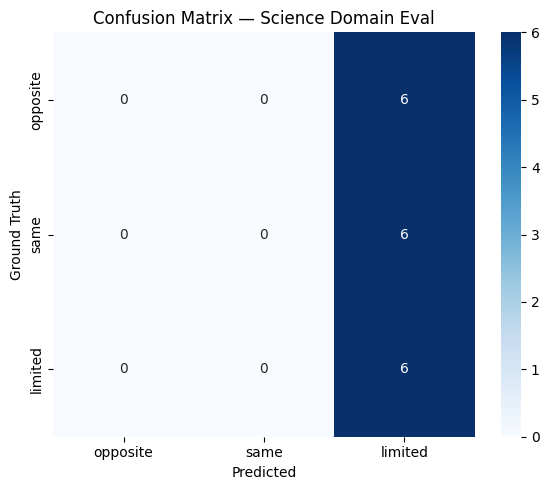


── 12 Misclassified pairs ──

  S1       : Aerobic respiration requires the presence of oxygen to oxidize glucose and produ...
  S2       : Anaerobic respiration occurs in the absence of oxygen, relying on fermentation p...
  Expected : opposite  |  Got: limited  (0.9981)
  Why hard : One requires oxygen, the other explicitly occurs without it — direct contradiction.

  S1       : The theory of quantum mechanics describes subatomic particles as existing in sup...
  S2       : Classical mechanics treats particles as having definite, deterministic positions...
  Expected : opposite  |  Got: limited  (0.9982)
  Why hard : Superposition/uncertainty vs deterministic/known — fundamental opposing frameworks.

  S1       : Vaccines stimulate the adaptive immune system by introducing antigens, prompting...
  S2       : Immunosuppressive drugs deliberately suppress the immune system's response, redu...
  Expected : opposite  |  Got: limited  (0.9901)
  Why hard : Vaccines boost immunity; immuno

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ── Ground Truth Dataset ───────────────────────────────────────────────────────
eval_data = [
    # (sentence1, sentence2, ground_truth_label, reasoning)

    # ── OPPOSITE ──────────────────────────────────────────────────────────────
    {
        "sentence1"   : "Aerobic respiration requires the presence of oxygen to oxidize glucose and produce ATP efficiently through the electron transport chain.",
        "sentence2"   : "Anaerobic respiration occurs in the absence of oxygen, relying on fermentation pathways that are far less efficient in ATP production.",
        "ground_truth": "opposite",
        "reasoning"   : "One requires oxygen, the other explicitly occurs without it — direct contradiction.",
    },
    {
        "sentence1"   : "The theory of quantum mechanics describes subatomic particles as existing in superposition states until observed or measured.",
        "sentence2"   : "Classical mechanics treats particles as having definite, deterministic positions and velocities that can be simultaneously known with arbitrary precision.",
        "ground_truth": "opposite",
        "reasoning"   : "Superposition/uncertainty vs deterministic/known — fundamental opposing frameworks.",
    },
    {
        "sentence1"   : "Vaccines stimulate the adaptive immune system by introducing antigens, prompting B-cells to produce specific antibodies for future defense.",
        "sentence2"   : "Immunosuppressive drugs deliberately suppress the immune system's response, reducing the body's ability to produce antibodies and fight infections.",
        "ground_truth": "opposite",
        "reasoning"   : "Vaccines boost immunity; immunosuppressants reduce it — opposite effects.",
    },
    {
        "sentence1"   : "Global warming accelerates the melting of polar ice caps, leading to a rise in sea levels and increased coastal flooding.",
        "sentence2"   : "The formation of polar ice sheets acts as a natural buffer against sea level rise by trapping large volumes of water in solid form.",
        "ground_truth": "opposite",
        "reasoning"   : "Ice melting raises sea levels vs ice formation prevents sea level rise.",
    },
    {
        "sentence1"   : "Neurons transmit electrical signals through action potentials, which are triggered when the membrane potential exceeds a threshold of approximately -55mV.",
        "sentence2"   : "During the refractory period following an action potential, the neuron is temporarily incapable of generating another signal regardless of stimulus intensity.",
        "ground_truth": "opposite",
        "reasoning"   : "Active signal firing vs complete inability to fire — opposing neuronal states.",
    },
    {
        "sentence1"   : "Black holes are regions of spacetime where gravity is so strong that nothing, including light or electromagnetic radiation, can escape beyond the event horizon.",
        "sentence2"   : "White holes, theorized as the time-reverse of black holes, are hypothetical regions that actively expel matter and energy, preventing anything from entering.",
        "ground_truth": "opposite",
        "reasoning"   : "Nothing escapes a black hole vs nothing enters a white hole — time-reversed opposites.",
    },

    # ── SAME ──────────────────────────────────────────────────────────────────
    {
        "sentence1"   : "DNA replication is a semi-conservative process in which each strand of the double helix serves as a template for synthesizing a new complementary strand.",
        "sentence2"   : "During DNA replication, the two parental strands are separated and each acts as a blueprint for building a new strand, resulting in two identical double-stranded molecules.",
        "ground_truth": "same",
        "reasoning"   : "Both describe semi-conservative replication using different vocabulary.",
    },
    {
        "sentence1"   : "Photosynthesis converts light energy into chemical energy stored in glucose, using carbon dioxide and water as reactants while releasing oxygen.",
        "sentence2"   : "During photosynthesis, plants harness solar radiation to synthesize carbohydrates from CO2 and H2O through a series of biochemical reactions, releasing O2 as a byproduct.",
        "ground_truth": "same",
        "reasoning"   : "Identical process described with different wording and chemical notation.",
    },
    {
        "sentence1"   : "Newton's second law of motion states that the acceleration of an object is directly proportional to the net force applied and inversely proportional to its mass.",
        "sentence2"   : "According to Newton's second law, a greater applied force produces a proportionally greater acceleration, while increasing mass results in proportionally reduced acceleration.",
        "ground_truth": "same",
        "reasoning"   : "F=ma expressed in two different phrasings — semantically identical.",
    },
    {
        "sentence1"   : "CRISPR-Cas9 functions as a molecular scissor that can locate and cut specific DNA sequences, enabling precise editing of the genome.",
        "sentence2"   : "The Cas9 protein, guided by an RNA sequence, introduces double-strand breaks at targeted genomic locations, allowing researchers to delete, correct, or insert genetic material.",
        "ground_truth": "same",
        "reasoning"   : "Both describe the same CRISPR-Cas9 mechanism at slightly different levels of detail.",
    },
    {
        "sentence1"   : "The central dogma of molecular biology describes the flow of genetic information from DNA to RNA through transcription, and from RNA to protein through translation.",
        "sentence2"   : "Genetic information flows unidirectionally in living cells: DNA is first transcribed into messenger RNA, which is subsequently translated by ribosomes into functional proteins.",
        "ground_truth": "same",
        "reasoning"   : "Same dogma described — transcription then translation — with different words.",
    },
    {
        "sentence1"   : "Mitosis is a type of cell division that produces two genetically identical daughter cells, each containing the same number of chromosomes as the parent cell.",
        "sentence2"   : "Unlike meiosis, mitosis results in daughter cells that are diploid and genetically identical to the original cell, preserving the full chromosomal complement.",
        "ground_truth": "same",
        "reasoning"   : "Both define mitosis as producing genetically identical diploid daughter cells.",
    },

    # ── LIMITED ───────────────────────────────────────────────────────────────
    {
        "sentence1"   : "The human brain consumes approximately 20% of the body's total energy despite accounting for only 2% of its total mass.",
        "sentence2"   : "The liver is the largest internal organ and performs over 500 functions including detoxification, protein synthesis, and regulation of blood glucose levels.",
        "ground_truth": "limited",
        "reasoning"   : "Both are human organ facts but describe entirely different organs and functions.",
    },
    {
        "sentence1"   : "Antibiotic resistance emerges when bacteria evolve mechanisms to survive exposure to drugs that would otherwise inhibit their growth or kill them.",
        "sentence2"   : "Viral infections replicate by hijacking the host cell's machinery, injecting genetic material and forcing the cell to produce thousands of viral copies.",
        "ground_truth": "limited",
        "reasoning"   : "Both are microbiology topics but discuss different organisms and mechanisms.",
    },
    {
        "sentence1"   : "The speed of light in a vacuum is approximately 299,792 kilometers per second, forming the universal speed limit in Einstein's theory of relativity.",
        "sentence2"   : "Quantum entanglement allows two particles to instantaneously share state information regardless of the distance separating them, challenging classical notions of locality.",
        "ground_truth": "limited",
        "reasoning"   : "Both are physics concepts but from different domains — relativity vs quantum mechanics.",
    },
    {
        "sentence1"   : "Stem cells are undifferentiated cells capable of self-renewal and differentiation into specialized cell types such as neurons, muscle, or blood cells.",
        "sentence2"   : "Neural plasticity refers to the brain's ability to reorganize synaptic connections in response to learning, experience, or recovery from injury.",
        "ground_truth": "limited",
        "reasoning"   : "Stem cells relate to cell biology; neural plasticity is a neuroscience concept — related domain, different topic.",
    },
    {
        "sentence1"   : "The Krebs cycle operates within the mitochondrial matrix and produces NADH and FADH2, which carry electrons to the electron transport chain.",
        "sentence2"   : "The sodium-potassium pump maintains the electrochemical gradient across the neuronal membrane by actively transporting three sodium ions out and two potassium ions in per cycle.",
        "ground_truth": "limited",
        "reasoning"   : "Both involve ion/electron transport at cellular level but in completely different contexts.",
    },
    {
        "sentence1"   : "Tectonic plate movement is driven by convection currents in the mantle, where heat from the Earth's core causes slow circulation of molten rock.",
        "sentence2"   : "Volcanic eruptions release large quantities of sulfur dioxide into the atmosphere, which can temporarily cool the Earth's surface by reflecting incoming solar radiation.",
        "ground_truth": "limited",
        "reasoning"   : "Both are Earth science topics but describe different phenomena — plate tectonics vs atmospheric chemistry.",
    },
]

# ── Run Evaluation ─────────────────────────────────────────────────────────────
df = pd.DataFrame(eval_data)

results = []
for _, row in df.iterrows():
    pred = predict_relation(row["sentence1"], row["sentence2"])
    results.append({
        "ground_truth": row["ground_truth"],
        "predicted"   : pred["relation"],
        "confidence"  : pred["confidence"],
        "correct"     : pred["relation"] == row["ground_truth"],
        "reasoning"   : row["reasoning"],
    })

results_df = pd.DataFrame(results)
df_eval    = pd.concat([df[["sentence1", "sentence2"]], results_df], axis=1)

# ── Print Results Table ────────────────────────────────────────────────────────
print("=" * 90)
print(f"{'#':<3} {'Ground Truth':<12} {'Predicted':<12} {'Conf':<7} {'OK':<5} Reasoning")
print("=" * 90)
for i, row in df_eval.iterrows():
    ok = "✅" if row["correct"] else "❌"
    print(f"{i:<3} {row['ground_truth']:<12} {row['predicted']:<12} {row['confidence']:<7} {ok}  {row['reasoning']}")

# ── Summary ────────────────────────────────────────────────────────────────────
correct = results_df["correct"].sum()
total   = len(results_df)
print(f"\nOverall accuracy : {correct}/{total} = {correct/total:.1%}")
print()
print(classification_report(
    results_df["ground_truth"],
    results_df["predicted"],
    target_names=LABELS,
))

# ── Confusion Matrix ───────────────────────────────────────────────────────────
cm = confusion_matrix(
    results_df["ground_truth"],
    results_df["predicted"],
    labels=LABELS,
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABELS,
    yticklabels=LABELS,
)
plt.xlabel("Predicted")
plt.ylabel("Ground Truth")
plt.title("Confusion Matrix — Science Domain Eval")
plt.tight_layout()
plt.show()

# ── Errors Only ────────────────────────────────────────────────────────────────
errors = df_eval[~df_eval["correct"]]
if len(errors) == 0:
    print("No errors — perfect score on this eval set!")
else:
    print(f"\n── {len(errors)} Misclassified pairs ──")
    for _, row in errors.iterrows():
        print(f"\n  S1       : {row['sentence1'][:80]}...")
        print(f"  S2       : {row['sentence2'][:80]}...")
        print(f"  Expected : {row['ground_truth']}  |  Got: {row['predicted']}  ({row['confidence']})")
        print(f"  Why hard : {row['reasoning']}")

## 12. (Optional) Fine-tune further on your own data

If you have domain-specific sentence pairs, add them here to boost performance on your custom distribution.

In [ ]:
from datasets import Dataset

my_data = {
    "sentence1": [
        "Photosynthesis converts light energy into chemical energy.",
        "The mitochondria is the powerhouse of the cell.",
        "Newton's second law states F = ma.",
        "Vaccines stimulate the immune system to produce antibodies.",
        "The derivative of x² is 2x.",
        "Atoms are the basic units of matter.",
        "The Earth orbits the Sun.",
        "Sound travels faster in water than in air.",
    ],
    "sentence2": [
        "Plants use sunlight to produce glucose from CO₂.",
        "Energy production in cells occurs in the mitochondria.",
        "Acceleration equals force divided by mass.",
        "Immunization prevents disease by training the immune system.",
        "Differentiating x squared gives two times x.",
        "Matter is made up of atoms.",
        "The Sun orbits the Earth.",
        "Light travels faster than sound.",
    ],
    "label": ["same", "same", "same", "same", "same", "same", "opposite", "limited"],
}

def preprocess_custom(examples):
    enc = tokenizer(
        examples["sentence1"],
        examples["sentence2"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    )
    enc["labels"] = [label2id[l] for l in examples["label"]]
    return enc

custom_ds = Dataset.from_dict(my_data).map(preprocess_custom, batched=True)
custom_ds.set_format("torch")

fine_tune_args = TrainingArguments(
    output_dir                  = "./bert-relation-custom",
    num_train_epochs            = 2,
    per_device_train_batch_size = 8,
    learning_rate               = 1e-5,
    weight_decay                = 0.01,
    evaluation_strategy         = "no",
    save_strategy               = "epoch",
    fp16                        = torch.cuda.is_available(),
    report_to                   = "none",
)

fine_tuner = Trainer(
    model         = model,
    args          = fine_tune_args,
    train_dataset = custom_ds,
)
fine_tuner.train()

model.save_pretrained("./bert-relation-custom-final")
tokenizer.save_pretrained("./bert-relation-custom-final")
print("Custom fine-tuned model saved.")

Map:   0%|          | 0/8 [00:00<?, ? examples/s]

TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'